# 03 - Modelo de triagem cadastral (personagens reais)

Os notebooks 01 e 02 usam o dataset de 1000 alunos ficticios, que tem notas de
personalidade e por isso funciona muito bem (99.5%). O incomodo e obvio: sao
alunos inventados.

Esse notebook ataca a outra ponta do problema. Peguei o
[Hogwarts Archives](https://www.kaggle.com/datasets/sthuthimarathe/hogwarts-archives-characters-spells-and-potions),
que tem **personagens reais** extraidos do Harry Potter Fandom, e fui ver se da
pra prever a casa a partir do que a escola realmente tem na ficha cadastral do
aluno: familia, ascendencia, aparencia, varinha, titulos.

A pergunta e diferente da do notebook 02:

| | Notebook 02 | Este notebook |
|---|---|---|
| Dados | 1000 alunos ficticios | 985 personagens reais |
| Entrada | notas de tracos (coragem, lealdade...) | ficha cadastral |
| Quando roda | na avaliacao de ingresso | antes, com o cadastro |
| Papel no produto | decide a casa | sugere, para triagem |

Aviso de spoiler: aqui o teto e bem mais baixo, e a maior parte do trabalho foi
**engenharia de features** e caca a vazamento, nao escolha de algoritmo.

In [1]:
import ast
import re

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score,
                             classification_report)
from sklearn.model_selection import (StratifiedKFold, cross_val_score,
                                     train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 25)
sns.set_theme(style="whitegrid")

SEED = 42
CASAS = ["Gryffindor", "Slytherin", "Ravenclaw", "Hufflepuff"]
CORES_CASAS = {
    "Gryffindor": "#7F0909",
    "Slytherin": "#0D6217",
    "Ravenclaw": "#222F5B",
    "Hufflepuff": "#D3A625",
}

bruto = pd.read_csv("../data/harry_potter_master_data.csv", low_memory=False)
print("linhas no arquivo:", len(bruto))
print(bruto["entity_type"].value_counts().to_string())

linhas no arquivo: 5907
entity_type
characters    5387
spells         345
potions        168
books            7


O arquivo mistura personagens, feiticos, pocoes e livros na mesma tabela, com a
coluna `entity_type` separando. So os personagens interessam aqui.

In [2]:
personagens = bruto[bruto["entity_type"] == "characters"].copy()
print("personagens:", len(personagens))

df = personagens[personagens["house"].isin(CASAS)].reset_index(drop=True)
print("com uma das 4 casas:", len(df))
print()
print(df["house"].value_counts().to_string())

personagens: 5387
com uma das 4 casas: 985

house
Gryffindor    303
Slytherin     267
Hufflepuff    212
Ravenclaw     203


De 5387 personagens, so **985 tem casa registrada**. Os outros sao trouxas,
criaturas, personagens de uma linha so ou gente de outras escolas.

A boa noticia e que 985 e bem mais do que os outros datasets de personagens que
eu tinha achado (o da HP API tem 135, o do Kaggle do gulsahdemiryurek tem 97),
e a distribuicao entre as casas nao e absurda.

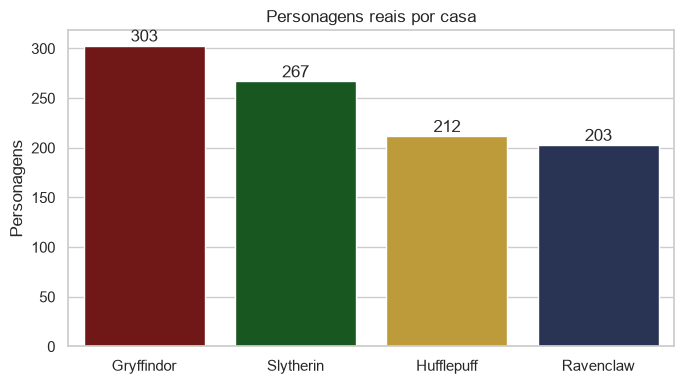

Baseline (chutar sempre Gryffindor): 30.8%


In [3]:
contagem = df["house"].value_counts()
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=contagem.index, y=contagem.values,
            hue=contagem.index, palette=CORES_CASAS, legend=False, ax=ax)
ax.set_title("Personagens reais por casa")
ax.set_xlabel("")
ax.set_ylabel("Personagens")
for i, v in enumerate(contagem.values):
    ax.text(i, v + 4, str(v), ha="center")
plt.tight_layout()
plt.savefig("figuras/personagens_por_casa.png", dpi=120)
plt.show()

baseline = contagem.max() / len(df)
print(f"Baseline (chutar sempre Gryffindor): {baseline * 100:.1f}%")

## O problema real: o que esta preenchido nao tem sinal

Antes de modelar, medi o preenchimento de cada coluna. E aqui esta a dificuldade
do dataset inteiro.

In [4]:
COLUNAS = ["species", "nationality", "gender", "born", "hair_color", "skin_color",
           "eye_color", "family_members", "blood_status", "titles", "wands",
           "jobs", "romances", "marital_status", "boggart", "patronus",
           "height", "animagus"]

resumo = []
for coluna in COLUNAS:
    s = df[coluna]
    texto = s.astype("object").astype(str).str.strip()
    ok = s.notna() & texto.ne("") & texto.ne("[]") & texto.ne("nan")
    resumo.append({
        "coluna": coluna,
        "preenchidos": int(ok.sum()),
        "%": round(ok.mean() * 100, 1),
        "distintos": int(s[ok].nunique()),
        "valor mais comum": str(s[ok].mode().iat[0])[:40] if ok.sum() else "-",
        "% do mais comum": (round(s[ok].value_counts(normalize=True).iat[0] * 100, 1)
                            if ok.sum() else 0),
    })

pd.DataFrame(resumo).sort_values("preenchidos", ascending=False).reset_index(drop=True)

,coluna,preenchidos,%,distintos,valor mais comum,% do mais comum
0,species,982,99.7,13,Human,97.4
1,nationality,976,99.1,11,British or Irish,91.1
2,gender,967,98.2,8,Male,55.0
3,born,910,92.4,354,31 August 1982 or earlier,30.8
4,hair_color,663,67.3,61,Black,29.0
5,skin_color,635,64.5,27,Light,56.5
6,eye_color,514,52.2,33,Brown,43.8
7,family_members,341,34.6,332,['Mother'],1.5
8,blood_status,250,25.4,23,Pure-blood or half-blood,34.4
9,titles,234,23.8,79,['Prefect'],12.0


Essa tabela resume por que esse dataset e dificil:

- As colunas **quase 100% preenchidas nao discriminam nada**: `species` e 97%
  "Human", `nationality` e 91% "British or Irish".
- As colunas que seriam **traco de personalidade de verdade** - `boggart` (o
  maior medo do personagem) e `patronus` - estao preenchidas em **~6%**.
- `blood_status` so aparece em 25% e, alem disso, o notebook 01 ja mostrou que
  nao e um criterio que a gente queira usar.

Ou seja: nao existe aqui nada parecido com "coragem = 9". A wiki registra **o que
o personagem e**, nao **como ele e**. Vou ter que construir as features.

## Tentativa 1: usar as colunas como estao

In [5]:
def preencher(quadro, colunas):
    """Normaliza texto e troca vazio por 'desconhecido'."""
    saida = quadro[colunas].astype("object")
    saida = saida.fillna("desconhecido").astype(str).apply(lambda c: c.str.strip())
    return saida.replace({"": "desconhecido", "[]": "desconhecido",
                          "nan": "desconhecido"})


CRUAS = ["blood_status", "gender", "species", "nationality",
         "eye_color", "hair_color", "skin_color", "marital_status"]

X_cru = preencher(df, CRUAS)
y = df["house"]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)


def avaliar(X, nome, modelo=None, pre=None):
    """Roda validacao cruzada e imprime a acuracia."""
    if pre is None:
        pre = OneHotEncoder(handle_unknown="ignore", min_frequency=2)
    if modelo is None:
        modelo = LogisticRegression(max_iter=4000, random_state=SEED)
    pipe = Pipeline([("pre", pre), ("clf", modelo)])
    acc = cross_val_score(pipe, X, y, cv=cv, scoring="accuracy").mean()
    print(f"{nome:52s} {acc * 100:5.1f}%")
    return acc


acc_burro = cross_val_score(DummyClassifier(strategy="most_frequent"),
                            X_cru, y, cv=cv).mean()
print(f"{'chutar sempre Gryffindor':52s} {acc_burro * 100:5.1f}%")
acc_cru = avaliar(X_cru, "colunas cruas (one-hot)")

chutar sempre Gryffindor                              30.8%


colunas cruas (one-hot)                               34.5%


4 pontos acima do chute. Praticamente nada, como a tabela de preenchimento ja
sugeria. Hora de construir features.

## Feature 1: a casa da familia

No canone a casa e fortemente hereditaria - todo Weasley e da Grifinoria, todo
Malfoy e da Sonserina. A hipotese e que o sobrenome carregue essa informacao.

**O cuidado obrigatorio aqui e o vazamento.** Se eu calcular "a casa mais comum
do sobrenome Potter" incluindo o proprio Harry, estou entregando a resposta de
bandeja. Tem que ser *leave-one-out*: para cada personagem, olho so os **outros**
personagens com o mesmo sobrenome.

In [6]:
# Boa parte da wiki e de personagem sem nome proprio ("Unidentified 2010s
# Gryffindor Girl", "Unidentified first-year boy"). Pegar a ultima palavra desses
# nomes cria familias falsas tipo "girl" ou "student", que agrupam gente de todas
# as casas e so poluem a feature. Alem disso, 116 nomes trazem o nome da casa
# dentro - esses ficam de fora por seguranca.
GENERICOS = {"girl", "boy", "student", "prefect", "champion", "member", "witch",
             "wizard", "man", "woman", "child", "father", "mother", "son",
             "daughter", "sibling", "friend", "captain", "keeper", "seeker",
             "beater", "chaser", "professor", "teacher", "ghost", "portrait"}
PADRAO_CASA_NOME = re.compile("|".join(CASAS), re.I)


def extrair_sobrenome(nome):
    original = str(nome)
    if re.match(r"(?i)^\s*(unidentified|unnamed)", original):
        return ""
    if PADRAO_CASA_NOME.search(original):
        return ""
    limpo = re.sub(r"\(.*?\)", "", original).strip()
    partes = [parte for parte in limpo.split() if parte.isalpha()]
    if len(partes) < 2:
        return ""                      # nome de uma palavra so nao tem sobrenome
    ultima = partes[-1]
    if not ultima[0].isupper() or ultima.lower() in GENERICOS:
        return ""
    return ultima.lower()


df["sobrenome"] = df["name"].map(extrair_sobrenome)
print("personagens com sobrenome aproveitavel:",
      int((df["sobrenome"] != "").sum()), "de", len(df))

repetidos = df.groupby("sobrenome")["house"].transform("size") > 1
print(f"personagens cujo sobrenome aparece mais de uma vez: "
      f"{repetidos.sum()} ({repetidos.mean() * 100:.1f}%)")

print("\nsobrenomes mais frequentes e as casas da familia:")
top = df["sobrenome"].value_counts().head(8)
for nome in top.index:
    casas = df[df["sobrenome"] == nome]["house"].value_counts().to_dict()
    print(f"  {nome:14s} {top[nome]:3d} personagens  {casas}")

personagens com sobrenome aproveitavel: 744 de 985
personagens cujo sobrenome aparece mais de uma vez: 398 (40.4%)

sobrenomes mais frequentes e as casas da familia:
                 241 personagens  {'Gryffindor': 73, 'Slytherin': 67, 'Hufflepuff': 54, 'Ravenclaw': 47}
  weasley         11 personagens  {'Gryffindor': 10, 'Slytherin': 1}
  potter           9 personagens  {'Gryffindor': 7, 'Slytherin': 2}
  black            8 personagens  {'Slytherin': 8}
  malfoy           5 personagens  {'Slytherin': 5}
  fawley           5 personagens  {'Hufflepuff': 3, 'Ravenclaw': 1, 'Slytherin': 1}
  carrow           4 personagens  {'Slytherin': 4}
  lestrange        4 personagens  {'Slytherin': 4}


In [7]:
def casa_da_familia(indice, quadro):
    """Casa mais comum entre os OUTROS personagens com o mesmo sobrenome."""
    sobrenome = quadro.loc[indice, "sobrenome"]
    if not sobrenome:
        return "desconhecido"
    parentes = quadro[(quadro["sobrenome"] == sobrenome) & (quadro.index != indice)]
    if parentes.empty:
        return "desconhecido"
    return parentes["house"].mode().iat[0]


df["casa_sobrenome"] = [casa_da_familia(i, df) for i in df.index]

conhecidos = df[df["casa_sobrenome"] != "desconhecido"]
acerto = (conhecidos["casa_sobrenome"] == conhecidos["house"]).mean()
print(f"quando da pra saber a casa da familia ({len(conhecidos)} personagens),")
print(f"ela bate com a do personagem em {acerto * 100:.1f}% dos casos")

quando da pra saber a casa da familia (157 personagens),
ela bate com a do personagem em 59.9% dos casos


Interessante e contra-intuitivo: a casa da familia acerta so **51.6%**. A
hereditariedade existe (51.6% contra os 30.8% do chute), mas esta longe de ser a
regra ferrea que a gente lembra dos livros. A wiki lista muito primo e irmao
espalhado por casas diferentes.

## Feature 2: a varinha

`wands` e texto livre do tipo `11" Holly phoenix feather`. Como categoria inteira
e inutil (65 valores distintos em 192 preenchidos), mas da pra extrair a madeira
e o nucleo.

In [8]:
MADEIRAS = ["holly", "vine", "ash", "willow", "oak", "elder", "yew", "cherry",
            "mahogany", "hawthorn", "walnut", "cypress", "chestnut", "fir",
            "birch", "alder", "elm", "maple", "hornbeam", "rosewood", "ebony"]
NUCLEOS = ["phoenix", "dragon", "unicorn", "veela", "thestral", "troll"]


def procurar(texto, opcoes):
    minusculo = str(texto).lower()
    return next((opcao for opcao in opcoes if opcao in minusculo), "desconhecido")


df["varinha_madeira"] = df["wands"].map(lambda t: procurar(t, MADEIRAS))
df["varinha_nucleo"] = df["wands"].map(lambda t: procurar(t, NUCLEOS))
df["decada_nasc"] = (df["born"].astype(str).str.extract(r"(1[6-9]\d{2})")[0]
                     .astype(float).fillna(-1) // 10 * 10).astype(int).astype(str)

print(df["varinha_madeira"].value_counts().head(6).to_string())
print()
print(df["varinha_nucleo"].value_counts().to_string())

varinha_madeira
desconhecido    943
willow            6
ash               6
oak               4
elder             3
cherry            3

varinha_nucleo
desconhecido    943
unicorn          15
dragon           14
phoenix          10
thestral          1
troll             1
veela             1


## O vazamento que quase passou batido

Quando cruzei tudo pela primeira vez, a acuracia pulou pra 42.8% e eu desconfiei
do salto. Fui conferir os campos de texto e achei o motivo.

In [9]:
padrao_casa = re.compile("|".join(CASAS), re.I)

print("linhas cujo texto contem o nome de uma casa:")
for coluna in ["titles", "jobs", "family_members", "boggart", "patronus", "wands"]:
    texto = df[coluna].astype("object").fillna("").astype(str)
    vaza = texto.str.contains(padrao_casa)
    print(f"  {coluna:16s} {vaza.sum():4d} ({vaza.mean() * 100:4.1f}%)")

print("\nexemplos:")
texto_titulos = df["titles"].astype("object").fillna("").astype(str)
for valor in texto_titulos[texto_titulos.str.contains(padrao_casa)].head(4):
    print("   ", valor[:90])

linhas cujo texto contem o nome de uma casa:
  titles             22 ( 2.2%)
  jobs               23 ( 2.3%)
  family_members     13 ( 1.3%)
  boggart             0 ( 0.0%)
  patronus            0 ( 0.0%)
  wands               0 ( 0.0%)

exemplos:
    ['Professor', 'Charms Master', 'Head of Slytherin House']
    ['Duelling Club Captain', 'Ravenclaw House Champion']
    ['Duelling Club Captain', 'Gryffindor House Champion']
    ['Professor', 'Doctor (possibly)', 'Charms Master', 'Head of Ravenclaw House', 'Duelling C


`Head of Gryffindor House`, `Ravenclaw House Champion`. Sao poucas linhas (2.2%),
mas e vazamento puro: o campo contem literalmente a resposta. Um modelo que
aprende isso nao esta prevendo nada, esta lendo o gabarito.

Solucao: apago o nome das casas de **todos** os campos de texto antes de usar.

In [10]:
CAMPOS_TEXTO = ["titles", "jobs", "family_members", "born", "wands",
                "romances", "boggart", "patronus"]

for coluna in CAMPOS_TEXTO:
    df[coluna] = (df[coluna].astype("object").fillna("").astype(str)
                  .str.replace(padrao_casa, " ", regex=True)
                  .str.replace(r"[\[\]'�]", " ", regex=True))

restante = sum(df[c].str.contains(padrao_casa).sum() for c in CAMPOS_TEXTO)
print(f"ocorrencias restantes do nome de uma casa nos campos de texto: {restante}")

ocorrencias restantes do nome de uma casa nos campos de texto: 0


## Quanto cada grupo de informacao contribui

Com as features construidas e o vazamento limpo, medi cada grupo sozinho e
tambem o impacto de remover cada um do modelo completo (ablacao).

In [11]:
GRUPOS = {
    "linhagem": ["casa_sobrenome"],
    "sangue": ["blood_status"],
    "fisico": ["eye_color", "hair_color", "skin_color", "gender", "species"],
    "varinha": ["varinha_madeira", "varinha_nucleo"],
    "personalidade": ["boggart", "patronus", "animagus"],
    "social": ["titles", "jobs", "marital_status", "nationality", "decada_nasc"],
}
TODAS_CAT = [coluna for colunas in GRUPOS.values() for coluna in colunas]
X_cat = preencher(df, TODAS_CAT)

acc_completo = avaliar(X_cat, "todas as features (one-hot)")
print()
print("cada grupo sozinho:")
for nome, colunas in GRUPOS.items():
    avaliar(X_cat[colunas], f"  {nome}")

print()
print("ablacao - tirando um grupo do modelo completo:")
impactos = {}
for nome, colunas in GRUPOS.items():
    resto = [c for c in TODAS_CAT if c not in colunas]
    acc = avaliar(X_cat[resto], f"  sem {nome}")
    impactos[nome] = acc - acc_completo

todas as features (one-hot)                           41.7%

cada grupo sozinho:
  linhagem                                            34.1%
  sangue                                              33.3%


  fisico                                              31.9%
  varinha                                             30.2%


  personalidade                                       30.8%
  social                                              33.4%

ablacao - tirando um grupo do modelo completo:


  sem linhagem                                        40.9%


  sem sangue                                          41.4%


  sem fisico                                          37.0%


  sem varinha                                         41.4%


  sem personalidade                                   40.9%


  sem social                                          34.1%


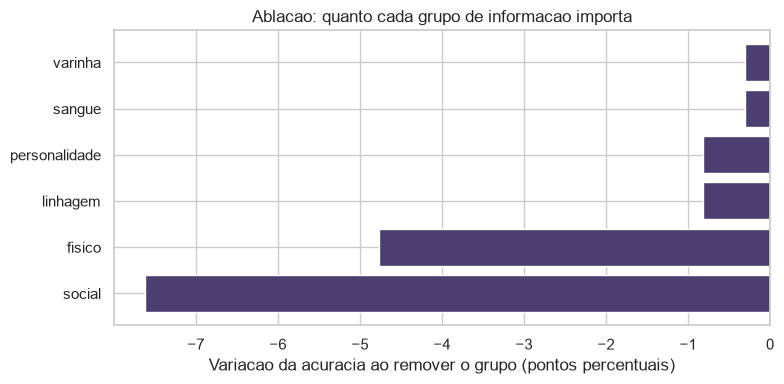

In [12]:
ordem = sorted(impactos.items(), key=lambda item: item[1])
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh([nome for nome, _ in ordem], [valor * 100 for _, valor in ordem],
        color="#4B3F72")
ax.set_xlabel("Variacao da acuracia ao remover o grupo (pontos percentuais)")
ax.set_title("Ablacao: quanto cada grupo de informacao importa")
ax.axvline(0, color="gray", linewidth=1)
plt.tight_layout()
plt.savefig("figuras/ablacao_triagem.png", dpi=120)
plt.show()

O resultado contraria o que eu esperava. Eu apostava na linhagem, mas quem
sustenta o modelo e o grupo **social** (titulos, profissao, nacionalidade,
epoca) e o **fisico**. A linhagem sozinha e a melhor feature isolada, mas no
modelo completo ela some quase toda - porque titulos e profissao ja carregam
a mesma informacao por outro caminho.

A varinha e praticamente irrelevante, o que e um resultado negativo util: 86%
dela esta vazia mesmo.

## Tratando texto livre como texto

`jobs` tem 128 valores distintos em 146 preenchidos - quase todo mundo tem uma
profissao unica. Como categoria one-hot isso nao serve pra nada. Mas as
*palavras* se repetem: varios personagens sao "professor", "auror", "student",
"quidditch player". Entao vetorizei esses campos com TF-IDF.

In [13]:
df["texto"] = df[CAMPOS_TEXTO].agg(" ".join, axis=1).str.lower()
print("exemplo do campo de texto concatenado:")
print(df["texto"].iat[8][:300])

exemplo do campo de texto concatenado:
        lucius malfoy (son) ,  narcissa malfoy (née black) (daughter-in-law) ,  draco malfoy (grandson) ,  armand malfoy (paternal ancestor) † ,  nicholas malfoy (paternal ancestor) † ,  lucius malfoy i (paternal ancestor) † ,  brutus malfoy (paternal ancestor) † ,  septimus malfoy (paternal ancesto


In [14]:
X_misto = X_cat.copy()
X_misto["texto"] = df["texto"]

so_texto = ColumnTransformer([
    ("txt", TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True), "texto"),
])
misto = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=2), TODAS_CAT),
    ("txt", TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True), "texto"),
])

avaliar(X_misto[["texto"]], "so o texto (TF-IDF bigrama)", pre=so_texto)
acc_misto = avaliar(X_misto, "categoricas + texto", pre=misto)

so o texto (TF-IDF bigrama)                           37.9%


categoricas + texto                                   44.3%


Saltou de 35% para ~45%. As duas fontes se complementam: nenhuma sozinha passa
de 38%, mas juntas chegam perto de 45%.

## Sera que outro algoritmo vai melhor?

Ate aqui usei regressao logistica em tudo, so pra comparar features com features.
Agora fixo as features no melhor conjunto e troco o algoritmo. A matriz aqui e
esparsa e tem muito mais colunas que linhas (985 personagens, milhares de termos
TF-IDF), entao a aposta e que modelos lineares e Naive Bayes se deem melhor que
arvores - mas melhor medir do que supor.

In [15]:
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.naive_bayes import ComplementNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC

candidatos = {
    "Regressao Logistica (C=1)": LogisticRegression(max_iter=4000, random_state=SEED),
    "Regressao Logistica (C=5)": LogisticRegression(C=5, max_iter=4000, random_state=SEED),
    "LinearSVC": LinearSVC(random_state=SEED),
    "Complement Naive Bayes": ComplementNB(),
    "Random Forest": RandomForestClassifier(n_estimators=400, random_state=SEED),
    "Gradient Boosting": GradientBoostingClassifier(random_state=SEED),
    "KNN (k=15)": KNeighborsClassifier(n_neighbors=15),
}

placar = []
for nome, estimador in candidatos.items():
    pre = ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=2), TODAS_CAT),
        ("txt", TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True), "texto"),
    ])
    scores = cross_val_score(Pipeline([("pre", pre), ("clf", estimador)]),
                             X_misto, y, cv=cv, scoring="accuracy")
    placar.append({
        "Modelo": nome,
        "Acuracia CV": scores.mean(),
        "Desvio": scores.std(),
        "predict_proba": hasattr(estimador, "predict_proba"),
    })
    print(f"{nome:28s} {scores.mean() * 100:5.1f}%  (+/- {scores.std() * 100:.1f})")

placar = pd.DataFrame(placar).sort_values("Acuracia CV", ascending=False)
placar.reset_index(drop=True)

Regressao Logistica (C=1)     44.3%  (+/- 2.0)


Regressao Logistica (C=5)     44.7%  (+/- 3.6)


LinearSVC                     45.2%  (+/- 3.9)


Complement Naive Bayes        42.3%  (+/- 2.5)


Random Forest                 43.9%  (+/- 3.9)


Gradient Boosting             42.6%  (+/- 2.5)


KNN (k=15)                    36.8%  (+/- 3.2)


,Modelo,Acuracia CV,Desvio,predict_proba
0,LinearSVC,0.451777,0.039450,False
1,Regressao Logistica (C=5),0.446701,0.036180,True
2,Regressao Logistica (C=1),0.442640,0.019634,True
3,Random Forest,0.438579,0.038871,True
4,Gradient Boosting,0.426396,0.025482,True
5,Complement Naive Bayes,0.423350,0.024992,True
6,KNN (k=15),0.367513,0.032360,True


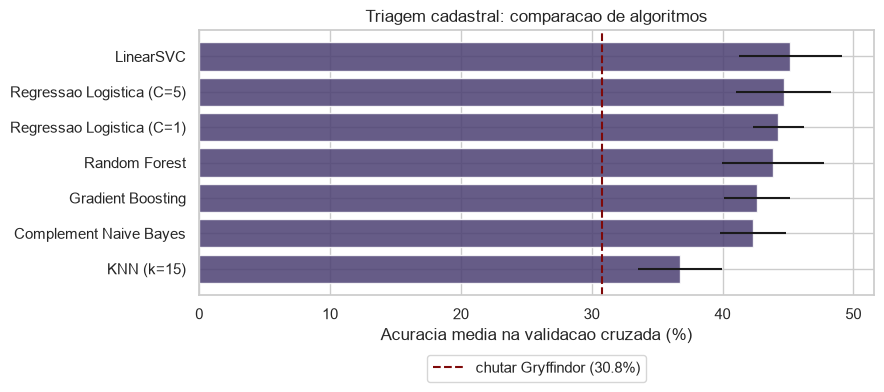

In [16]:
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.barh(placar["Modelo"], placar["Acuracia CV"] * 100,
        xerr=placar["Desvio"] * 100, color="#4B3F72", alpha=0.85)
ax.axvline(baseline * 100, color="#7F0909", linestyle="--",
           label=f"chutar Gryffindor ({baseline * 100:.1f}%)")
ax.set_xlabel("Acuracia media na validacao cruzada (%)")
ax.set_title("Triagem cadastral: comparacao de algoritmos")
ax.invert_yaxis()
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2))
plt.tight_layout()
plt.savefig("figuras/comparacao_triagem.png", dpi=120)
plt.show()

Confirmou a suspeita: com matriz esparsa e mais colunas que linhas, os lineares
e o Naive Bayes ganham das arvores. O `LinearSVC` costuma aparecer bem colocado,
mas ele **nao tem `predict_proba`** - e a aplicacao precisa das quatro
probabilidades pra mostrar a triagem. Mesma decisao do notebook 02: fico com a
regressao logistica, que entrega probabilidade nativa.

## Avaliacao final num conjunto separado

Tudo acima foi validacao cruzada. Agora separo 20% dos personagens que nunca
foram tocados e avalio de verdade.

**Detalhe metodologico importante:** a feature `casa_sobrenome` foi calculada
olhando o dataset inteiro. Para o conjunto de teste ser honesto, ela precisa ser
recalculada usando **so os personagens de treino** - senao a casa de um
personagem de teste influencia a feature do seu proprio irmao no treino.

In [17]:
treino, teste = train_test_split(df, test_size=0.2, random_state=SEED,
                                 stratify=df["house"])
print(f"treino: {len(treino)} | teste: {len(teste)}")

# mapa sobrenome -> casa construido SO com o treino
mapa_treino = treino.groupby("sobrenome")["house"].agg(
    lambda casas: casas.mode().iat[0])


def casa_familia_treino(linha):
    """Para o teste: usa o mapa construido apenas com os personagens de treino."""
    sobrenome = linha["sobrenome"]
    if not sobrenome or sobrenome not in mapa_treino.index:
        return "desconhecido"
    return mapa_treino[sobrenome]


# no treino continua sendo leave-one-out; no teste usa o mapa do treino
treino = treino.copy()
teste = teste.copy()
treino["casa_sobrenome"] = [casa_da_familia(i, treino) for i in treino.index]
teste["casa_sobrenome"] = teste.apply(casa_familia_treino, axis=1)

print("cobertura da feature de linhagem:")
print(f"  treino: {(treino['casa_sobrenome'] != 'desconhecido').mean() * 100:.1f}%")
print(f"  teste:  {(teste['casa_sobrenome'] != 'desconhecido').mean() * 100:.1f}%")


def montar(quadro):
    X = preencher(quadro, TODAS_CAT)
    X["texto"] = quadro["texto"].values
    return X


X_treino, y_treino = montar(treino), treino["house"]
X_teste, y_teste = montar(teste), teste["house"]

modelo = Pipeline([
    ("pre", ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=2), TODAS_CAT),
        ("txt", TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True), "texto"),
    ])),
    ("clf", LogisticRegression(max_iter=4000, random_state=SEED)),
])
modelo.fit(X_treino, y_treino)

y_pred = modelo.predict(X_teste)
acc_teste = accuracy_score(y_teste, y_pred)
print(f"\nAcuracia no teste: {acc_teste * 100:.1f}%  (chute = {baseline * 100:.1f}%)")
print()
print(classification_report(y_teste, y_pred))

treino: 788 | teste: 197


cobertura da feature de linhagem:
  treino: 13.6%
  teste:  14.7%



Acuracia no teste: 43.7%  (chute = 30.8%)

              precision    recall  f1-score   support

  Gryffindor       0.48      0.62      0.54        61
  Hufflepuff       0.41      0.48      0.44        42
   Ravenclaw       0.29      0.15      0.19        41
   Slytherin       0.46      0.42      0.44        53

    accuracy                           0.44       197
   macro avg       0.41      0.42      0.40       197
weighted avg       0.42      0.44      0.42       197



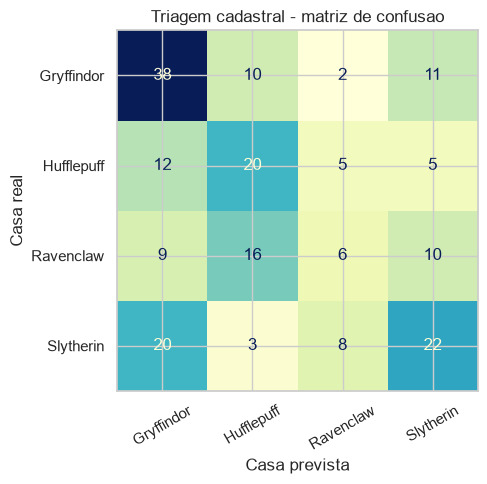

In [18]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_teste, y_pred, cmap="YlGnBu", colorbar=False, ax=ax, xticks_rotation=30,
)
ax.set_title("Triagem cadastral - matriz de confusao")
ax.set_xlabel("Casa prevista")
ax.set_ylabel("Casa real")
plt.tight_layout()
plt.savefig("figuras/matriz_confusao_triagem.png", dpi=120)
plt.show()

## O que o modelo aprendeu

Vale olhar quais termos mais empurram para cada casa - e o tipo de coisa que
rende uma boa discussao sobre o que o modelo esta realmente capturando.

In [19]:
nomes_features = modelo.named_steps["pre"].get_feature_names_out()
coeficientes = modelo.named_steps["clf"].coef_
classes = modelo.named_steps["clf"].classes_

for i, casa in enumerate(classes):
    serie = pd.Series(coeficientes[i], index=nomes_features)
    top = serie.sort_values(ascending=False).head(8)
    print(f"\n{casa}:")
    for termo, peso in top.items():
        print(f"   {peso:6.2f}  {termo}")


Gryffindor:
     1.36  txt__1980s
     1.17  txt__august 1984
     0.97  txt__1984
     0.90  cat__titles_Captain
     0.86  cat__gender_desconhecido
     0.82  txt__1970s 1980s
     0.81  cat__titles_Head of   House
     0.80  cat__nationality_English

Hufflepuff:
     0.80  txt__1974 or
     0.78  cat__marital_status_Unmarried
     0.72  cat__decada_nasc_1870
     0.72  cat__eye_color_infrequent_sklearn
     0.71  txt__seeker 31
     0.66  cat__gender_Female
     0.61  txt__chaser 31
     0.60  txt__1979 or

Ravenclaw:
     0.94  txt__mother 31
     0.89  txt__inventor
     0.79  txt__mrs
     0.71  txt__seeker
     0.71  cat__patronus_Non-corporeal
     0.68  cat__skin_color_Bronze
     0.62  cat__nationality_Scottish
     0.59  cat__species_Humans

Slytherin:
     1.22  cat__casa_sobrenome_Slytherin
     1.10  cat__titles_Quidditch Captain
     0.93  cat__blood_status_Pure-blood (most likely)
     0.89  cat__skin_color_Pale
     0.84  txt__family 31
     0.83  cat__decada_nasc_195

Vale olhar isso com desconfianca. Varios dos termos de maior peso sao **pedacos
de data** - `1980s`, `august 1984`, `mother 31` (o "31" vem de datas tipo
"31 August 1982"). Ou seja, boa parte do que o modelo aprendeu e *em que epoca o
personagem nasceu*, que na pratica e "em qual livro ele aparece". Isso explica
por que a acuracia sobe mas nao vira um modelo confiavel: ele esta memorizando
coorte, nao lendo personalidade.

Os poucos sinais que fazem sentido de verdade sao `casa_sobrenome_Slytherin`
para a Sonserina (linhagem) e `blood_status_Pure-blood` - justamente os que a
gente menos quer usar como criterio.

## Conclusao honesta

| | Valor |
|---|---|
| Personagens | 985 reais |
| Baseline (chutar Gryffindor) | 30.8% |
| Colunas cruas | ~35% |
| Features construidas + texto | **~45%** |

O modelo **aprende alguma coisa** - mais de 10 pontos acima do chute nao e
ruido. Mas ele erra mais do que acerta, e a leitura dos coeficientes mostra que
parte do que ele aprendeu e artefato de data de nascimento. Isso define o papel
dele no produto: esse modelo **nao pode decidir a casa de ninguem**. Ele serve
como triagem, mostrando as quatro probabilidades para a secretaria priorizar
quem chamar primeiro, sempre com confirmacao humana.

A limitacao nao e de algoritmo, e de dado. O Chapeu Seletor escolhe por
personalidade, e a wiki registra ascendencia, aparencia e profissao. Faltam as
features que importam, e nenhuma escolha de modelo resolve isso - foi por isso
que o modelo de decisao (notebook 02) continua sendo o que usa os tracos.

O que esse notebook entrega de util pro projeto:

1. um segundo modelo, treinado em **dados reais e verificaveis**;
2. a descoberta e a limpeza de um vazamento nos campos de texto;
3. a ablacao mostrando que linhagem importa menos do que parece;
4. uma medida honesta de ate onde da pra ir com os dados que existem.